In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dataset = pd.read_excel('HousePricePrediction.xlsx')
dataset[:5]
# dataset.head() - Same


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [2]:
dataset.shape

(2919, 13)

In [3]:
# Data Preprocessing
# let's find the categorical variable
object_cols = dataset.select_dtypes(include=['object']).columns
print("Categorical Variables:", len(object_cols))

# Interger variable
int_ = dataset.select_dtypes(include=['int64']).columns
print("Integer Variables:", len(int_))

# Float type variables
float_ = dataset.select_dtypes(include=['float64']).columns
print("Float Variables:", len(float_))

Categorical Variables: 4
Integer Variables: 6
Float Variables: 3


Heat map saved


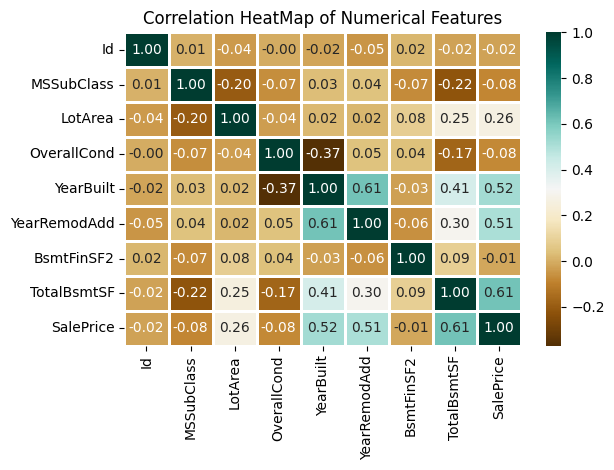

In [4]:
# EDA {Exporatory Data Analysis}
# We will use heatmap using seaborn to see cor function

numerical_dataset = dataset.select_dtypes(include=['Float64', 'int64'])

plt.Figure(figsize=(12, 6))
sns.heatmap(numerical_dataset.corr(), cmap='BrBG', fmt='.2f', linewidths=2, annot=True)
plt.title("Correlation HeatMap of Numerical Features")
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
print("Heat map saved")

<Axes: title={'center': 'No. of Unique values of Categorical Features'}, xlabel='None'>

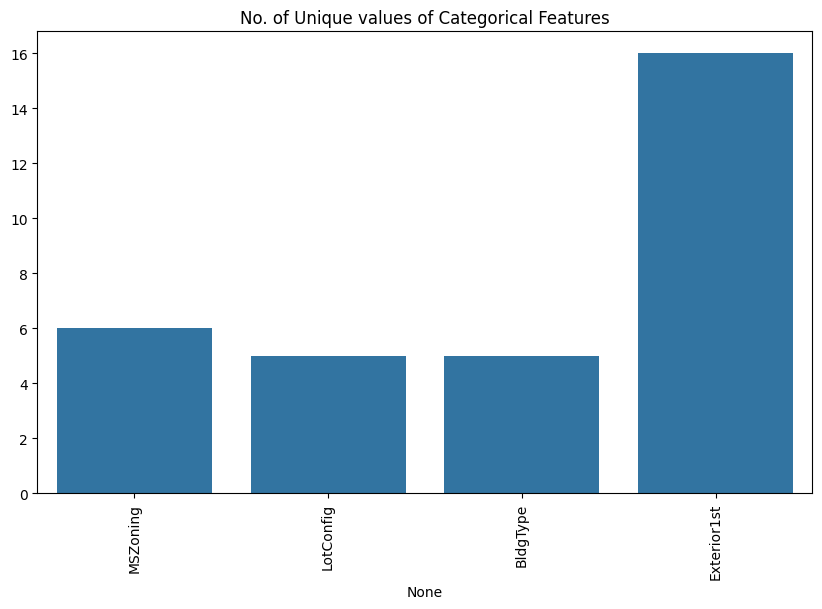

In [5]:
# We will create barplot to see their distributions
unique_values = []
for col in object_cols:
    unique_values.append(dataset[col].unique().size)

plt.figure(figsize=(10,6))
plt.title("No. of Unique values of Categorical Features")
plt.xticks(rotation=90)
sns.barplot(x=object_cols, y=unique_values)

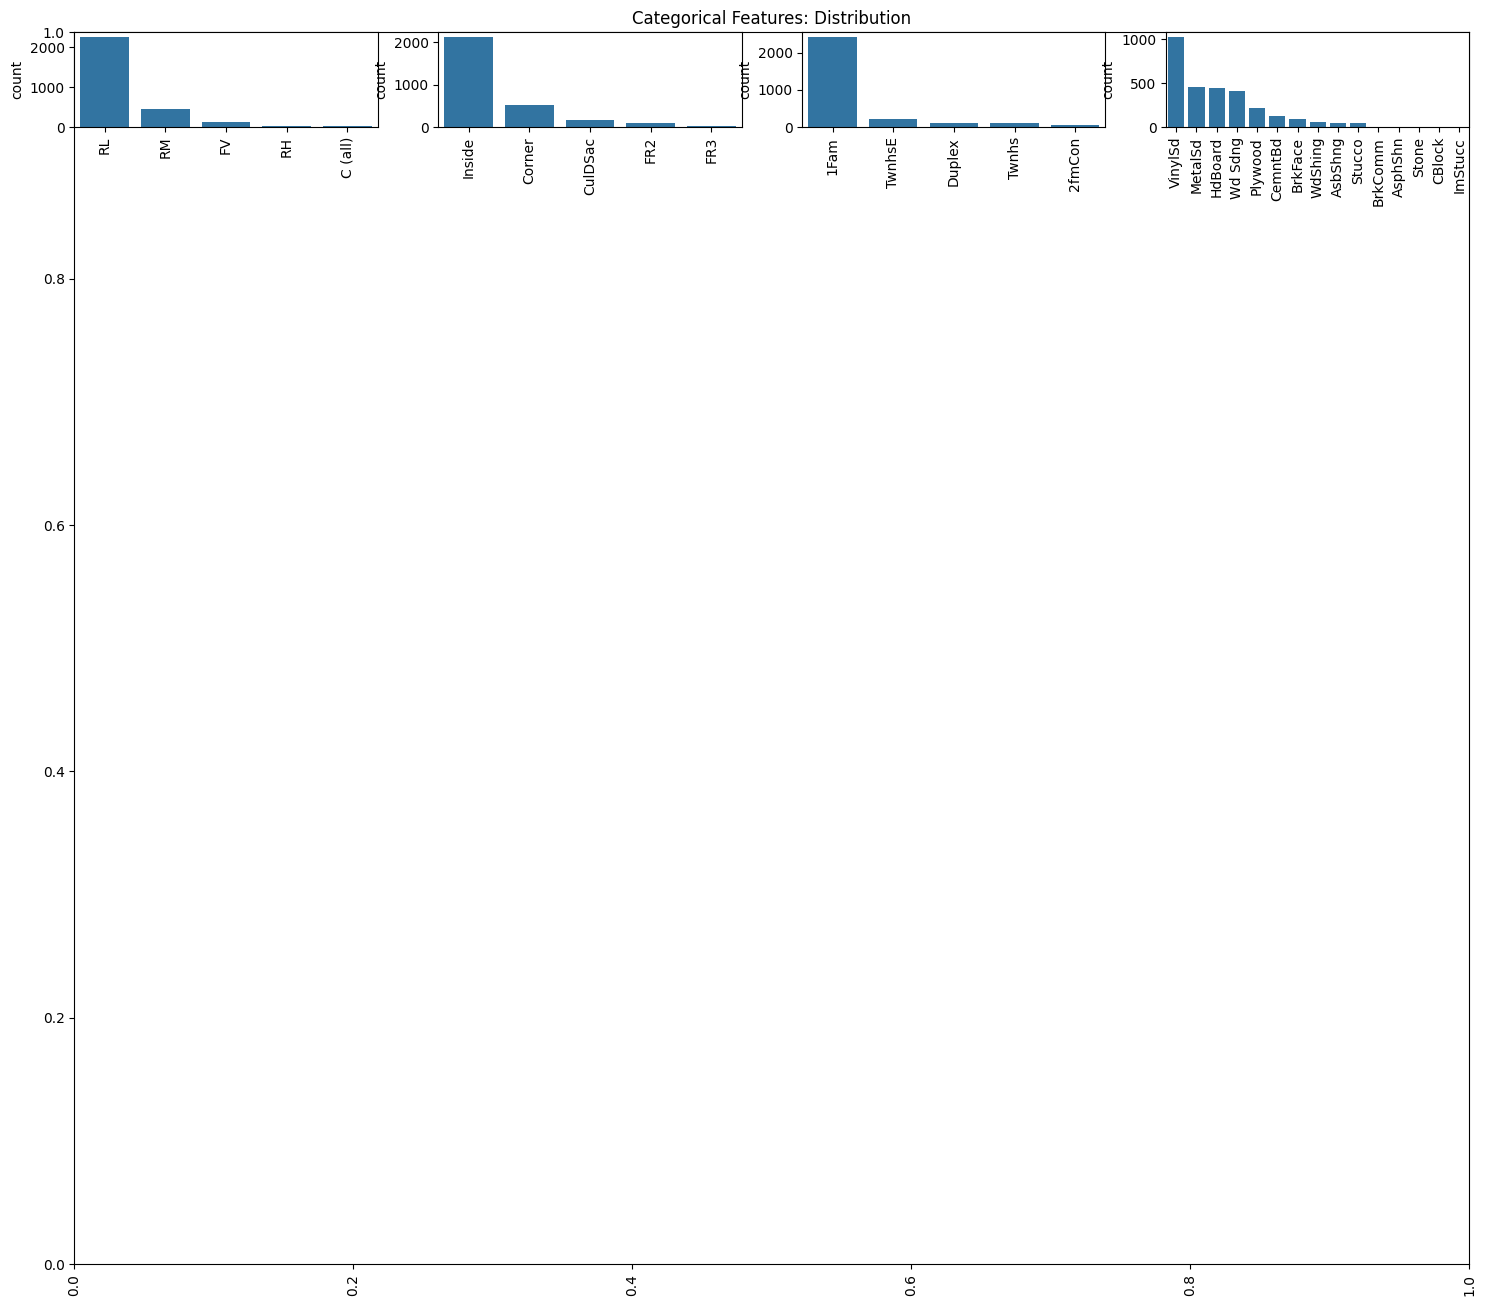

In [15]:
# Findout the actual count of each category we can plot the bargraph of each four features
plt.figure(figsize=(18,16))
plt.title("Categorical Features: Distribution")
plt.xticks(rotation=90)
index=1

for col in object_cols:
    y = dataset[col].value_counts()
    plt.subplot(11, 4, index)
    plt.xticks(rotation=90)
    sns.barplot(x=list(y.index), y=y)
    index += 1

In [7]:
# Data Cleaning
# let's drop the id column, it not imp
dataset.drop(['Id'], axis=1, inplace=True)

In [8]:
# let's repalce the emply value with their mea value
dataset['SalePrice'] = dataset['SalePrice'].fillna(dataset['SalePrice'].mean())

In [9]:
# Drop the record with null values
new_dataset = dataset.dropna()

In [10]:
# Checking null values if there are
new_dataset.isnull().sum().sum()

np.int64(0)

In [11]:
# Important: Ont Hot Encoder - For Label Categorical Features
from sklearn.preprocessing import OneHotEncoder

s = (new_dataset.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical Variables:")
print(object_cols)
print("No. of. Categorical features: ", len(object_cols))

Categorical Variables:
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
No. of. Categorical features:  4


In [12]:
# Once we have list of all features. We can apply OneHotEncoder to the whole list
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(new_dataset[object_cols]))
OH_cols.index = new_dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = new_dataset.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)

In [13]:
# Splitting the dataset into training and testing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X = df_final.drop(['SalePrice'], axis=1)
y = df_final['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## SVM - Suport Vector Machine

In [16]:
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_percentage_error

model_SVR = svm.SVR()
model_SVR.fit(X_train, y_train)
Y_pred = model_SVR.predict(X_test)

print(mean_absolute_percentage_error(y_test, Y_pred))

0.20686498946192633


## Random Forest Regression

In [19]:
from sklearn.ensemble import RandomForestClassifier

model_RFR = RandomForestClassifier(n_estimators=100, random_state=42)
model_RFR.fit(X_train, y_train)
Y_pred = model_RFR.predict(X_test)

print(mean_absolute_percentage_error(y_test, Y_pred))

ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

## linear Regresssion

In [20]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
Y_pred = model_lr.predict(X_test)

print(mean_absolute_percentage_error(Y_pred, y_test))

0.18131930971717983
